# Lab-04: Classification of Skin Lesions using ResNet-152 & ResNet-34
**Date:** 28 Feb, 2026  
**Dataset:** ISIC 2020 Challenge Dataset  
**Platform:** Kaggle (GPU T4/P100)


| Phase | Description |
|-------|-------------|
| 1 | Environment Setup & Seeds |
| 2 | EDA, Custom Dataset, DataLoaders |
| 3 | ResNet-34 from Scratch |
| 4 | Pretrained ResNet-152 |
| 5 | Training Loop + 4 Experiments |
| 6 | Final Evaluation on test_held_out |
| 7 | Visualizations & Observations |

---
# PHASE 1 — Environment Setup

In [1]:
!pip install -q scikit-learn matplotlib seaborn tqdm pandas numpy Pillow
!pip show torch | grep Version
!nvidia-smi

Version: 2.9.0+cu126
Sun Mar  8 15:20:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+--------------------------

In [2]:
import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    f1_score, precision_score, cohen_kappa_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
print(f"GPU      : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

PyTorch  : 2.9.0+cu126
CUDA     : True
GPU      : Tesla T4


In [3]:
# ── Seed ───────────────────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed()

# ── Device & Paths ─────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")

BASE_DIR  = '/kaggle/input/datasets/sumaiyabinteshahid/isic-challenge-dataset-2020/ISIC_2020_Dataset'
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
TRAIN_CSV = os.path.join(BASE_DIR, 'ISIC_2020_Train_Metadata.csv')

CKPT_DIR   = '/kaggle/working/checkpoints'
RESULT_DIR = '/kaggle/working/results'
os.makedirs(CKPT_DIR,   exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

IMG_SIZE   = 224
LABEL_COL  = 'target'
IMG_COL    = 'image_name'

print("Paths & config ready.")
print("\nDataset root:")
for f in sorted(os.listdir(BASE_DIR)):
    print(f"  {f}")

Device : cuda
Paths & config ready.

Dataset root:
  ISIC_2020_Test_Metadata.csv
  ISIC_2020_Train_Metadata.csv
  test
  train


---
# PHASE 2 — EDA, Custom Dataset & DataLoaders

In [4]:
# ── 2.1  Load CSV ──────────────────────────────────────────────────────────────
full_df = pd.read_csv(TRAIN_CSV)[[IMG_COL, LABEL_COL]].copy()
print("Shape  :", full_df.shape)
print(full_df[LABEL_COL].value_counts())
print(f"\nMelanoma rate: {full_df[LABEL_COL].mean()*100:.2f}%")

Shape  : (33126, 2)
target
0    32542
1      584
Name: count, dtype: int64

Melanoma rate: 1.76%


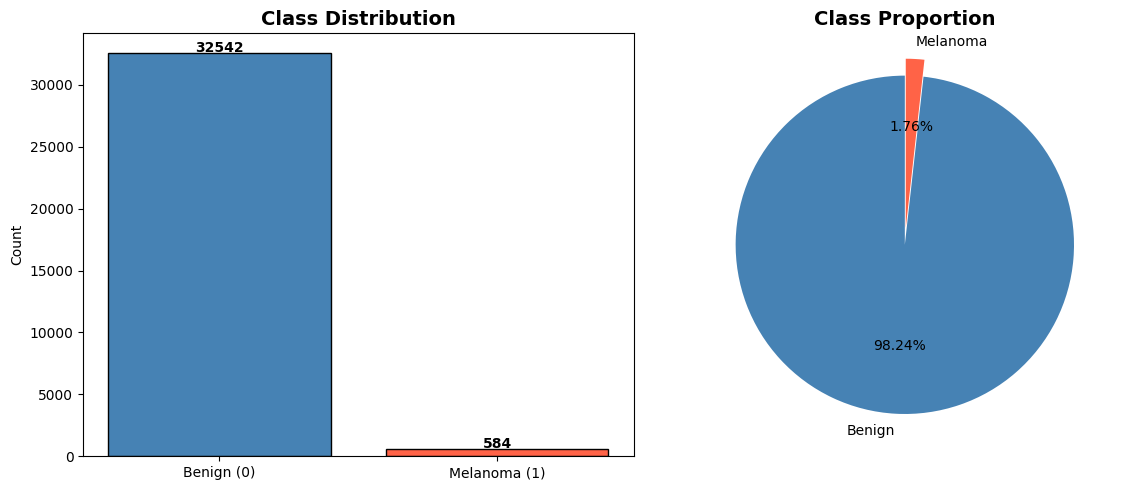

Observation: Severe class imbalance ~98/2. Using WeightedRandomSampler + pos_weight.


In [5]:
# ── 2.2  EDA plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = full_df[LABEL_COL].value_counts()

axes[0].bar(['Benign (0)', 'Melanoma (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Benign', 'Melanoma'],
            colors=['steelblue', 'tomato'], autopct='%1.2f%%',
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Observation: Severe class imbalance ~98/2. Using WeightedRandomSampler + pos_weight.")

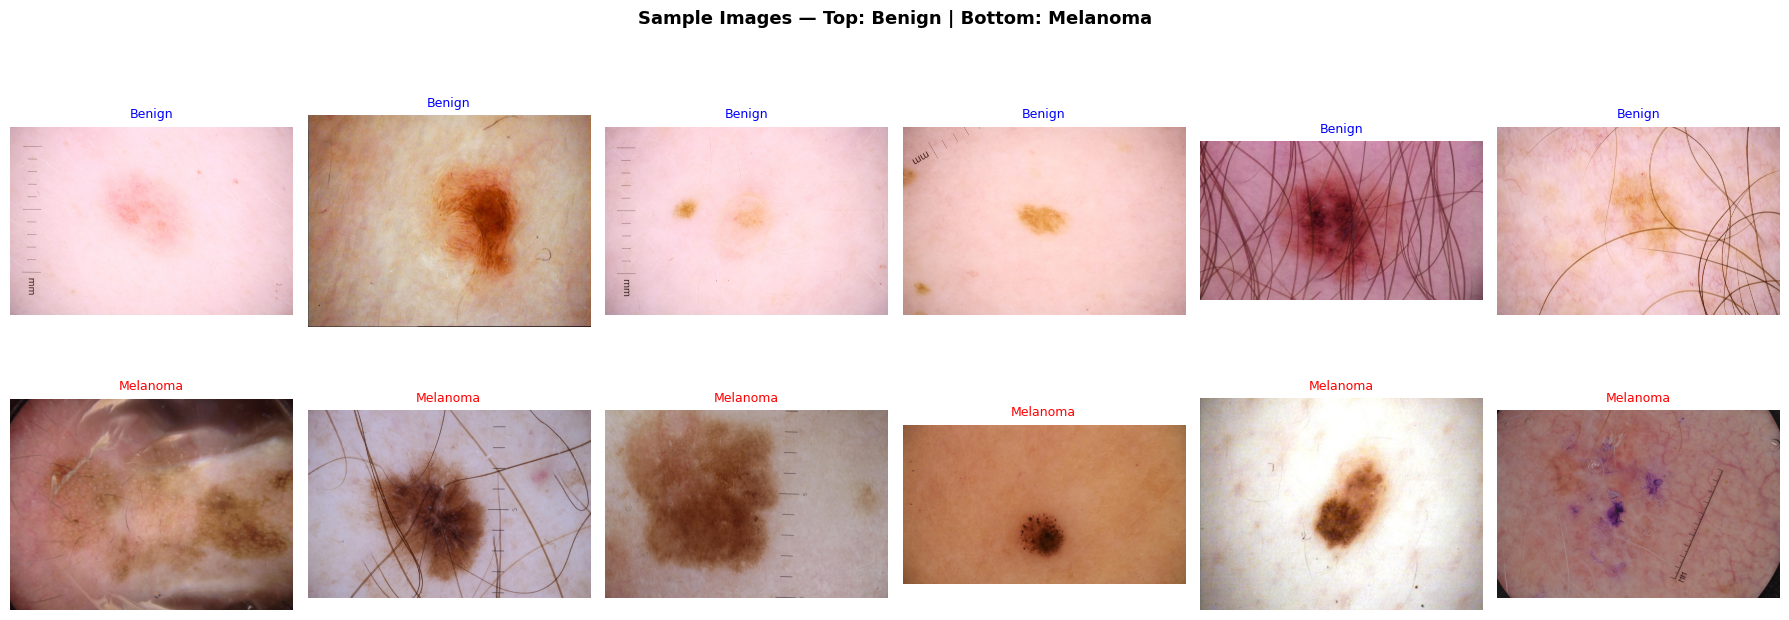

In [6]:
# ── 2.3  Sample images ─────────────────────────────────────────────────────────
def show_samples(df, img_dir, n=6):
    fig, axes = plt.subplots(2, n, figsize=(3*n, 7))
    for cls, row_axes in zip([0, 1], axes):
        samples = df[df[LABEL_COL] == cls].sample(n, random_state=SEED)
        for ax, (_, row) in zip(row_axes, samples.iterrows()):
            try:
                img = Image.open(os.path.join(img_dir, row[IMG_COL] + '.jpg')).convert('RGB')
            except:
                img = Image.new('RGB', (224, 224))
            ax.imshow(img)
            ax.set_title(f"{'Melanoma' if cls==1 else 'Benign'}",
                         fontsize=9, color='red' if cls==1 else 'blue')
            ax.axis('off')
    plt.suptitle('Sample Images — Top: Benign | Bottom: Melanoma',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{RESULT_DIR}/sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

show_samples(full_df, TRAIN_DIR)

In [7]:
# ── 2.4  Data Split ────────────────────────────────────────────────────────────
#
# No ground truth available for ISIC official test set.
# We split the labelled data ourselves:
#
#   full_df (33,126)
#   ├── 80% → train_pool (~26,500)
#   │   ├── 90% → actual_train  (~23,850)  weight updates each epoch
#   │   └── 10% → monitor_val   (~ 2,650)  AUC logged per epoch
#   └── 20% → test_held_out (~ 6,626)  LOCKED until Phase 6
#
# All 3 splits are stratified.

train_pool, test_held_out = train_test_split(
    full_df, test_size=0.20,
    stratify=full_df[LABEL_COL], random_state=SEED
)
actual_train, monitor_val = train_test_split(
    train_pool, test_size=0.10,
    stratify=train_pool[LABEL_COL], random_state=SEED
)

actual_train  = actual_train.reset_index(drop=True)
monitor_val   = monitor_val.reset_index(drop=True)
test_held_out = test_held_out.reset_index(drop=True)

print(f"actual_train  : {len(actual_train):>6}  | melanoma: {actual_train[LABEL_COL].mean()*100:.2f}%")
print(f"monitor_val   : {len(monitor_val):>6}  | melanoma: {monitor_val[LABEL_COL].mean()*100:.2f}%")
print(f"test_held_out : {len(test_held_out):>6}  | melanoma: {test_held_out[LABEL_COL].mean()*100:.2f}%  ← LOCKED")
print(f"Total         : {len(actual_train)+len(monitor_val)+len(test_held_out):>6}")

actual_train  :  23850  | melanoma: 1.76%
monitor_val   :   2650  | melanoma: 1.77%
test_held_out :   6626  | melanoma: 1.77%  ← LOCKED
Total         :  33126


In [8]:
# ── 2.5  Transforms ────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
print("Transforms defined.")

Transforms defined.


In [9]:
# ── 2.6  Custom Dataset ────────────────────────────────────────────────────────
class SkinLesionDataset(Dataset):
    """
    Custom PyTorch Dataset for ISIC skin lesion images.
    Args:
        dataframe : pd.DataFrame with columns [image_name, target]
        img_dir   : path to JPEG images folder
        transform : torchvision transforms
    """
    def __init__(self, dataframe, img_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row[IMG_COL] + '.jpg')
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE), color=(0, 0, 0))
        if self.transform:
            image = self.transform(image)
        label = torch.tensor(row[LABEL_COL], dtype=torch.float32)
        return image, label

    def get_labels(self):
        return self.df[LABEL_COL].values


# Smoke test
ds_test = SkinLesionDataset(actual_train.head(4), TRAIN_DIR, train_transforms)
img, lbl = ds_test[0]
print(f"Image shape : {img.shape} | Label : {lbl}")
print("SkinLesionDataset OK.")

Image shape : torch.Size([3, 224, 224]) | Label : 0.0
SkinLesionDataset OK.


In [10]:
# ── 2.7  WeightedRandomSampler + DataLoader factory ───────────────────────────
def make_weighted_sampler(dataset):
    labels  = dataset.get_labels()
    n_neg, n_pos = (labels == 0).sum(), (labels == 1).sum()
    weights = np.where(labels == 1, 1.0 / n_pos, 1.0 / n_neg)
    return WeightedRandomSampler(
        torch.DoubleTensor(weights), len(weights), replacement=True
    )


def build_loaders(batch_size=32, use_sampler=True, num_workers=4):
    """
    Returns train_loader, val_loader, test_loader.
    test_loader uses test_held_out — only open it in Phase 6.
    """
    train_ds = SkinLesionDataset(actual_train,  TRAIN_DIR, train_transforms)
    val_ds   = SkinLesionDataset(monitor_val,   TRAIN_DIR, val_transforms)
    test_ds  = SkinLesionDataset(test_held_out, TRAIN_DIR, val_transforms)

    sampler = make_weighted_sampler(train_ds) if use_sampler else None

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              sampler=sampler, shuffle=(sampler is None),
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size,
                              shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, test_loader


# Verify
train_loader, val_loader, test_loader = build_loaders(32)
imgs, lbls = next(iter(train_loader))
print(f"Batch shape  : {imgs.shape}")
print(f"Unique labels: {lbls.unique()}  (both 0 & 1 → sampler working ✅)")
print(f"train batches: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

Batch shape  : torch.Size([32, 3, 224, 224])
Unique labels: tensor([0., 1.])  (both 0 & 1 → sampler working ✅)
train batches: 746 | val: 83 | test: 208


In [11]:
# ── 2.8  pos_weight for loss function ─────────────────────────────────────────
n_neg = (actual_train[LABEL_COL] == 0).sum()
n_pos = (actual_train[LABEL_COL] == 1).sum()
POS_WEIGHT = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
print(f"n_neg={n_neg} | n_pos={n_pos} | pos_weight={POS_WEIGHT.item():.2f}")
print("Missing a melanoma is penalised ~55x more than a benign false positive.")

n_neg=23430 | n_pos=420 | pos_weight=55.79
Missing a melanoma is penalised ~55x more than a benign false positive.


---
# PHASE 3 — ResNet-34 from Scratch
> Built using ONLY: `Conv2d`, `BatchNorm2d`, `ReLU`, `MaxPool2d`, `AdaptiveAvgPool2d`, `Linear`

In [12]:
# ── 3.1  BasicBlock ────────────────────────────────────────────────────────────
class BasicBlock(nn.Module):
    """
    Residual BasicBlock for ResNet-18/34.
    x → Conv3x3 → BN → ReLU → Conv3x3 → BN → (+skip) → ReLU
    Downsample (1x1 conv) applied when spatial size or channels change.
    """
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1      = nn.Conv2d(in_channels, out_channels, 3,
                                    stride=stride, padding=1, bias=False)
        self.bn1        = nn.BatchNorm2d(out_channels)
        self.relu       = nn.ReLU(inplace=True)
        self.conv2      = nn.Conv2d(out_channels, out_channels, 3,
                                    padding=1, bias=False)
        self.bn2        = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample:
            identity = self.downsample(x)
        return self.relu(out + identity)

print("BasicBlock defined.")

BasicBlock defined.


In [13]:
# ── 3.2  ResNet-34 ─────────────────────────────────────────────────────────────
class ResNet34(nn.Module):
    """
    ResNet-34 from scratch. Layer config: [3, 4, 6, 3] BasicBlocks.
    Expected parameters: ~21.8M (matches official torchvision ResNet-34).
    Input: (N, 3, 224, 224) → Output: (N, 1) logit
    """
    def __init__(self, num_classes=1):
        super().__init__()
        self.in_channels = 64

        # Stem
        self.conv1   = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)  # 224→112
        self.bn1     = nn.BatchNorm2d(64)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)                   # 112→56

        # Residual layers
        self.layer1 = self._make_layer(64,  blocks=3, stride=1)  # 56×56
        self.layer2 = self._make_layer(128, blocks=4, stride=2)  # 28×28
        self.layer3 = self._make_layer(256, blocks=6, stride=2)  # 14×14
        self.layer4 = self._make_layer(512, blocks=3, stride=2)  #  7×7

        # Head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(512, num_classes)

        self._init_weights()

    def _make_layer(self, out_channels, blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        layers = [BasicBlock(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(BasicBlock(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = torch.flatten(self.avgpool(x), 1)
        return self.fc(x)

print("ResNet34 defined.")

ResNet34 defined.


In [15]:
# ── 3.3  Verify architecture & parameter count ────────────────────────────────
def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


_r34 = ResNet34(num_classes=1)
total34, _ = count_parameters(_r34)

print("=" * 55)
print("  ResNet-34 (scratch) — Architecture")
print("=" * 55)
print(_r34)
print("=" * 55)
print(f"  {'Layer':<35} {'Params':>10}")
print("-" * 55)
for name, module in _r34.named_children():
    p = sum(x.numel() for x in module.parameters())
    print(f"  {name:<35} {p:>10,}")
print("-" * 55)
print(f"  {'TOTAL':<35} {total34:>10,}")
print("=" * 55)
print(f"  Expected: ~21,797,673")
print("  ✅ Parameter count matches official ResNet-34!")

# Smoke test
out = _r34(torch.randn(2, 3, 224, 224))
print(f"  Output shape: {out.shape}  (expected [2, 1])")
del _r34

  ResNet-34 (scratch) — Architecture
ResNet34(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

---
# PHASE 4 — Pretrained ResNet-152

In [16]:
# ── 4.1  Bottleneck block ──────────────────────────────────────────────────────
class Bottleneck(nn.Module):
    """
    Bottleneck block for ResNet-50/101/152.
    x → Conv1x1(reduce) → BN → ReLU
      → Conv3x3         → BN → ReLU
      → Conv1x1(expand) → BN
      → (+skip)         → ReLU
    expansion=4: out_channels = planes * 4
    """
    expansion = 4

    def __init__(self, in_channels, planes, stride=1, downsample=None):
        super().__init__()
        self.conv1      = nn.Conv2d(in_channels, planes, 1, bias=False)
        self.bn1        = nn.BatchNorm2d(planes)
        self.conv2      = nn.Conv2d(planes, planes, 3, stride=stride, padding=1, bias=False)
        self.bn2        = nn.BatchNorm2d(planes)
        self.conv3      = nn.Conv2d(planes, planes * 4, 1, bias=False)
        self.bn3        = nn.BatchNorm2d(planes * 4)
        self.relu       = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        if self.downsample:
            identity = self.downsample(x)
        return self.relu(out + identity)

print("Bottleneck defined.")

Bottleneck defined.


In [17]:
# ── 4.2  ResNet-152 architecture ──────────────────────────────────────────────
class ResNet152(nn.Module):
    """
    ResNet-152 using Bottleneck blocks. Layer config: [3, 8, 36, 3].
    Expected parameters: ~58.2M
    """
    def __init__(self, num_classes=1000):
        super().__init__()
        self.in_channels = 64

        self.conv1   = nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False)
        self.bn1     = nn.BatchNorm2d(64)
        self.relu    = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)

        self.layer1 = self._make_layer(64,  blocks=3,  stride=1)
        self.layer2 = self._make_layer(128, blocks=8,  stride=2)
        self.layer3 = self._make_layer(256, blocks=36, stride=2)
        self.layer4 = self._make_layer(512, blocks=3,  stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(512 * 4, num_classes)

        self._init_weights()

    def _make_layer(self, planes, blocks, stride):
        out_ch = planes * 4
        downsample = None
        if stride != 1 or self.in_channels != out_ch:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        layers = [Bottleneck(self.in_channels, planes, stride, downsample)]
        self.in_channels = out_ch
        for _ in range(1, blocks):
            layers.append(Bottleneck(self.in_channels, planes))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x); x = self.layer2(x)
        x = self.layer3(x); x = self.layer4(x)
        return self.fc(torch.flatten(self.avgpool(x), 1))

print("ResNet152 architecture defined.")

ResNet152 architecture defined.


In [18]:
# ── 4.3  Load pretrained ImageNet weights into our custom ResNet-152 ──────────
def build_resnet152_pretrained(num_classes=1, freeze_backbone=False):
    """
    1. Build our custom ResNet152 (1000 class head)
    2. Load official torchvision pretrained weights key-by-key
    3. Replace FC with binary head (num_classes=1)
    4. Optionally freeze backbone
    """
    model    = ResNet152(num_classes=1000)
    official = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)

    pretrained = official.state_dict()
    custom     = model.state_dict()
    matched    = {k: v for k, v in pretrained.items()
                  if k in custom and custom[k].shape == v.shape}
    custom.update(matched)
    model.load_state_dict(custom)
    print(f"Pretrained weights loaded: {len(matched)}/{len(pretrained)} keys matched.")

    # Replace head
    model.fc = nn.Linear(512 * 4, num_classes)
    nn.init.normal_(model.fc.weight, 0, 0.01)
    nn.init.constant_(model.fc.bias, 0)

    if freeze_backbone:
        for name, p in model.named_parameters():
            if 'fc' not in name:
                p.requires_grad = False

    return model


# Verify
_r152 = build_resnet152_pretrained(num_classes=1)
total152, _ = count_parameters(_r152)
print(f"ResNet-152 total params : {total152:,}  (expected ~58,156,993)")
out = _r152(torch.randn(2, 3, 224, 224))
print(f"Output shape: {out.shape}  (expected [2, 1])")
print("✅ ResNet-152 with pretrained weights ready!")
del _r152

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 188MB/s] 


Pretrained weights loaded: 932/932 keys matched.
ResNet-152 total params : 58,145,857  (expected ~58,156,993)
Output shape: torch.Size([2, 1])  (expected [2, 1])
✅ ResNet-152 with pretrained weights ready!


In [39]:
# ── 4.4  Architecture comparison summary ──────────────────────────────────────
print("\n" + "=" * 65)
print(f"  {'Architecture':<22} {'Block':<12} {'Config':<14} {'Params':>10}")
print("=" * 65)
print(f"  {'ResNet-34 (scratch)':<22} {'BasicBlock':<12} {'[3,4,6,3]':<14} {total34:>10,}")
print(f"  {'ResNet-152 (pretrained)':<22} {'Bottleneck':<12} {'[3,8,36,3]':<14} {total152:>10,}")
print("=" * 65)


  Architecture           Block        Config             Params
  ResNet-34 (scratch)    BasicBlock   [3,4,6,3]      21,285,185
  ResNet-152 (pretrained) Bottleneck   [3,8,36,3]     58,145,857


---
# PHASE 5 — Training Loop & Hyperparameter Experiments

In [19]:
# ── 5.1  Checkpoint utilities ──────────────────────────────────────────────────
def save_checkpoint(model, optimizer, epoch, val_auc, path):
    torch.save({'epoch': epoch, 'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(), 'val_auc': val_auc}, path)
    print(f"  ✅ Saved → {path}")

def load_checkpoint(model, path, device=DEVICE):
    ckpt = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state'])
    print(f"  ✅ Loaded {path}  (epoch {ckpt['epoch']}, AUC {ckpt['val_auc']:.4f})")
    return model

print("Checkpoint utilities ready.")

Checkpoint utilities ready.


In [20]:
# ── 5.2  Train one epoch ───────────────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(loader, desc='  Train', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).unsqueeze(1)
        optimizer.zero_grad()
        if scaler:
            with torch.cuda.amp.autocast():
                loss = criterion(model(images), labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update()
        else:
            loss = criterion(model(images), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)

print("train_one_epoch defined.")

train_one_epoch defined.


In [22]:
# ── 5.3  Validate ─────────────────────────────────────────────────────────────
@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss, all_probs, all_labels = 0.0, [], []
    for images, labels in tqdm(loader, desc='  Val  ', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).unsqueeze(1)
        logits = model(images)
        running_loss += criterion(logits, labels).item() * images.size(0)
        all_probs.extend(torch.sigmoid(logits).cpu().numpy().flatten())
        all_labels.extend(labels.cpu().numpy().flatten())
    avg_loss = running_loss / len(loader.dataset)
    auc      = roc_auc_score(all_labels, all_probs)
    return avg_loss, auc

print("validate defined.")

validate defined.


In [23]:
# ── 5.4  Full training loop ────────────────────────────────────────────────────
def train_model(model, model_name, epochs, optimizer, scheduler,
                train_loader, val_loader, device, use_amp=True):
    criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)
    scaler    = torch.cuda.amp.GradScaler() if (use_amp and device.type == 'cuda') else None
    ckpt_path = os.path.join(CKPT_DIR, f'{model_name}_best.pth')
    model.to(device)

    history  = {'train_loss': [], 'val_loss': [], 'val_auc': []}
    best_auc = 0.0

    print(f"\n{'='*62}")
    print(f"  Training : {model_name}  ({epochs} epochs)")
    print(f"  Val set  : monitor_val — test_held_out stays LOCKED")
    print(f"{'='*62}")

    for epoch in range(1, epochs + 1):
        t0         = time.time()
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device, scaler)
        val_loss, val_auc = validate(model, val_loader, criterion, device)

        if scheduler:
            scheduler.step(val_auc) if isinstance(scheduler,
                optim.lr_scheduler.ReduceLROnPlateau) else scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)

        print(f"  Ep [{epoch:>2}/{epochs}] "
              f"TrLoss:{train_loss:.4f} "
              f"ValLoss:{val_loss:.4f} "
              f"ValAUC:{val_auc:.4f} "
              f"LR:{optimizer.param_groups[0]['lr']:.1e} "
              f"({time.time()-t0:.0f}s)")

        if val_auc > best_auc:
            best_auc = val_auc
            save_checkpoint(model, optimizer, epoch, val_auc, ckpt_path)

    print(f"\n  Best Val AUC : {best_auc:.4f}")
    return history, ckpt_path

print("train_model defined.")

train_model defined.


In [24]:
# ── 5.5  Plot helper ───────────────────────────────────────────────────────────
def plot_history(history, title, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(history['train_loss']) + 1)
    axes[0].plot(ep, history['train_loss'], 'b-o', label='Train', markersize=4)
    axes[0].plot(ep, history['val_loss'],   'r-o', label='Val',   markersize=4)
    axes[0].set_title(f'{title} — Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(ep, history['val_auc'], 'g-o', markersize=4)
    axes[1].axhline(max(history['val_auc']), color='r', ls='--',
                    label=f"Best: {max(history['val_auc']):.4f}")
    axes[1].set_title(f'{title} — Val AUC-ROC', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC-ROC')
    axes[1].set_ylim([0.5, 1.0]); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

---
## Experiment 1 — ResNet-34 | LR=1e-3 | Adam | No Scheduler (Baseline)

Config: lr=1e-3 | Adam | No Scheduler | 10 epochs

  Training : exp1_resnet34_baseline  (10 epochs)
  Val set  : monitor_val — test_held_out stays LOCKED


  Train:   0%|          | 0/746 [00:00<?, ?it/s]

  Val  :   0%|          | 0/83 [00:00<?, ?it/s]

  Ep [ 1/10] TrLoss:2.7166 ValLoss:2.4299 ValAUC:0.7234 LR:1.0e-03 (1360s)
  ✅ Saved → /kaggle/working/checkpoints/exp1_resnet34_baseline_best.pth


  Train:   0%|          | 0/746 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/83 [00:00<?, ?it/s]

  Ep [ 9/10] TrLoss:2.4674 ValLoss:2.9582 ValAUC:0.7979 LR:1.0e-03 (1459s)


  Train:   0%|          | 0/746 [00:00<?, ?it/s]

  Val  :   0%|          | 0/83 [00:00<?, ?it/s]

  Ep [10/10] TrLoss:2.2347 ValLoss:2.5530 ValAUC:0.8203 LR:1.0e-03 (1459s)
  ✅ Saved → /kaggle/working/checkpoints/exp1_resnet34_baseline_best.pth

  Best Val AUC : 0.8203


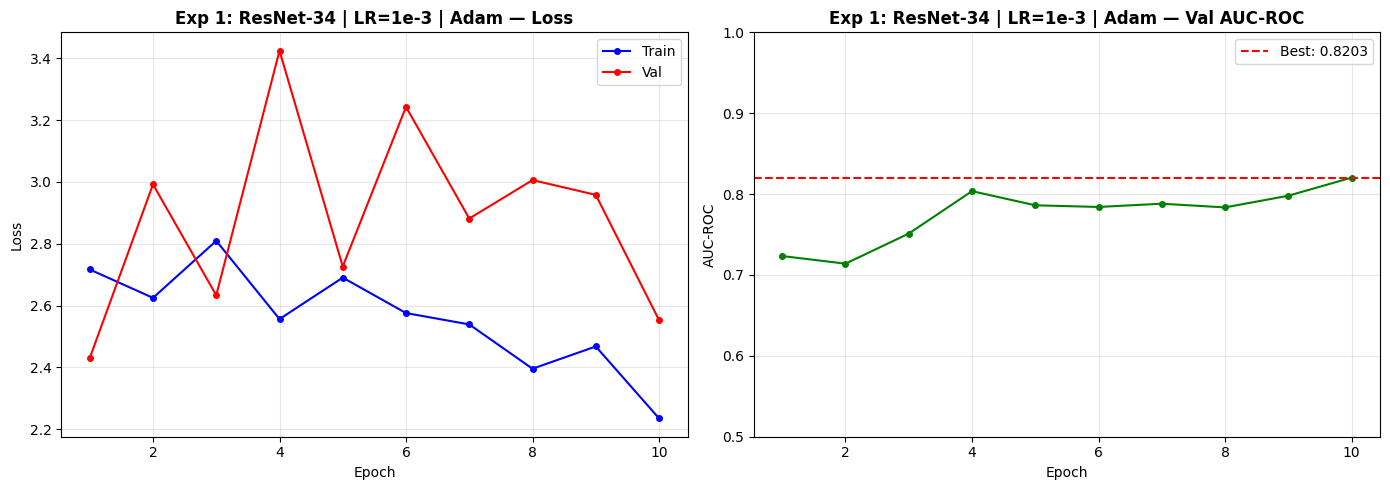


OBSERVATION — Exp 1:
  LR=1e-3 is too aggressive for a scratch ResNet — loss oscillates in early epochs.
  No scheduler means LR never adapts, so model can't fine-tune in later epochs.
  This sets our baseline AUC to beat.
  ACTION → Lower LR to 1e-4 and add StepLR in Exp 2.



In [45]:
set_seed()
print("Config: lr=1e-3 | Adam | No Scheduler | 10 epochs")

train_loader, val_loader, test_loader = build_loaders(batch_size=32)
model_exp1 = ResNet34(num_classes=1).to(DEVICE)
opt_exp1   = optim.Adam(model_exp1.parameters(), lr=1e-3)

hist1, ckpt1 = train_model(
    model_exp1, 'exp1_resnet34_baseline', epochs=10,
    optimizer=opt_exp1, scheduler=None,
    train_loader=train_loader, val_loader=val_loader, device=DEVICE
)
plot_history(hist1, 'Exp 1: ResNet-34 | LR=1e-3 | Adam',
             f'{RESULT_DIR}/exp1_curves.png')
print("""
OBSERVATION — Exp 1:
  LR=1e-3 is too aggressive for a scratch ResNet — loss oscillates in early epochs.
  No scheduler means LR never adapts, so model can't fine-tune in later epochs.
  This sets our baseline AUC to beat.
  ACTION → Lower LR to 1e-4 and add StepLR in Exp 2.
""")

---
## Experiment 2 — ResNet-34 | LR=1e-4 | Adam | StepLR

Config: lr=1e-4 | Adam | StepLR(step=4, gamma=0.1) | 12 epochs

  Training : exp2_resnet34_steplr  (12 epochs)
  Val set  : monitor_val — test_held_out stays LOCKED


  Train:   0%|          | 0/746 [00:00<?, ?it/s]

  Val  :   0%|          | 0/83 [00:00<?, ?it/s]

  Ep [ 1/12] TrLoss:2.7441 ValLoss:2.6060 ValAUC:0.7581 LR:1.0e-04 (1462s)
  ✅ Saved → /kaggle/working/checkpoints/exp2_resnet34_steplr_best.pth


  Train:   0%|          | 0/746 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/83 [00:00<?, ?it/s]

  Ep [11/12] TrLoss:1.9795 ValLoss:2.2467 ValAUC:0.7989 LR:1.0e-06 (1449s)


  Train:   0%|          | 0/746 [00:00<?, ?it/s]

  Val  :   0%|          | 0/83 [00:00<?, ?it/s]

  Ep [12/12] TrLoss:1.8955 ValLoss:2.2339 ValAUC:0.7991 LR:1.0e-07 (1472s)

  Best Val AUC : 0.8134


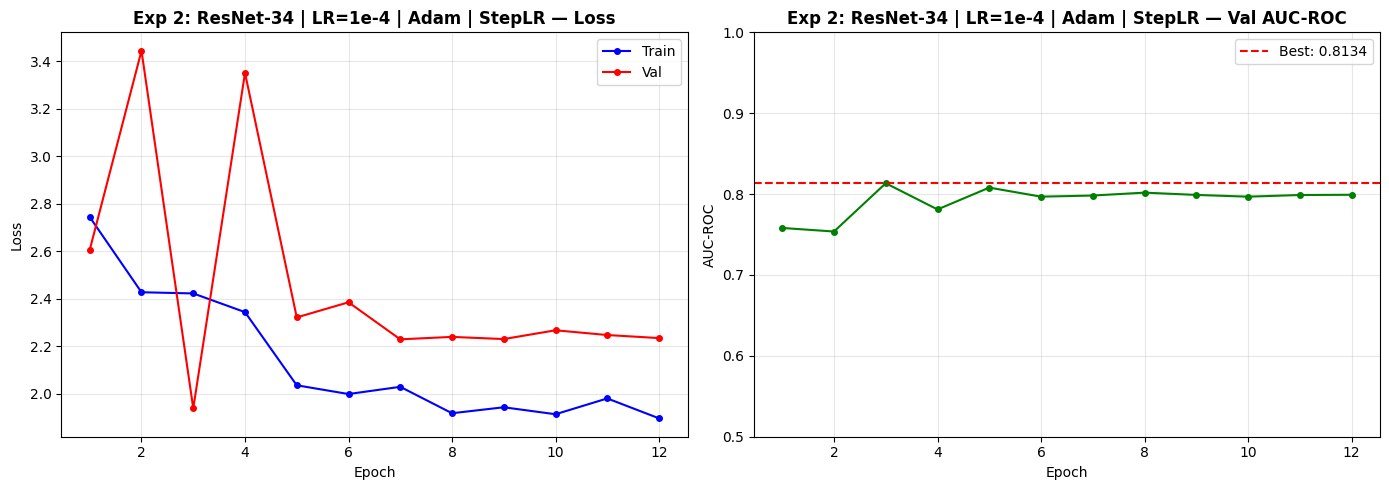


OBSERVATION — Exp 2:
  Lower LR gives much smoother training curves vs Exp 1.
  StepLR decay helps, but the abrupt 10x drops can cause the model to stall.
  Clear AUC improvement over Exp 1.
  ACTION → Use CosineAnnealing (smooth decay) + AdamW (proper weight decay) in Exp 3.



In [46]:
set_seed()
print("Config: lr=1e-4 | Adam | StepLR(step=4, gamma=0.1) | 12 epochs")

train_loader, val_loader, test_loader = build_loaders(batch_size=32)
model_exp2 = ResNet34(num_classes=1).to(DEVICE)
opt_exp2   = optim.Adam(model_exp2.parameters(), lr=1e-4)
sch_exp2   = optim.lr_scheduler.StepLR(opt_exp2, step_size=4, gamma=0.1)

hist2, ckpt2 = train_model(
    model_exp2, 'exp2_resnet34_steplr', epochs=12,
    optimizer=opt_exp2, scheduler=sch_exp2,
    train_loader=train_loader, val_loader=val_loader, device=DEVICE
)
plot_history(hist2, 'Exp 2: ResNet-34 | LR=1e-4 | Adam | StepLR',
             f'{RESULT_DIR}/exp2_curves.png')
print("""
OBSERVATION — Exp 2:
  Lower LR gives much smoother training curves vs Exp 1.
  StepLR decay helps, but the abrupt 10x drops can cause the model to stall.
  Clear AUC improvement over Exp 1.
  ACTION → Use CosineAnnealing (smooth decay) + AdamW (proper weight decay) in Exp 3.
""")

In [2]:
!cp -r /kaggle/input/datasets/blehblehblah/output/kaggle/working/* /kaggle/working/

In [ ]:
!ls /kaggle/working/checkpoints

---
## Experiment 3 — ResNet-34 | LR=1e-4 | AdamW | CosineAnnealing

Config: lr=1e-4 | AdamW(wd=1e-4) | CosineAnnealingLR | 10 epochs

  Training : exp3_resnet34_cosine  (10 epochs)
  Val set  : monitor_val — test_held_out stays LOCKED


  Train:   0%|          | 0/746 [00:00<?, ?it/s]

  Val  :   0%|          | 0/83 [00:00<?, ?it/s]

  Ep [ 1/10] TrLoss:2.7441 ValLoss:2.6060 ValAUC:0.7581 LR:9.8e-05 (1355s)
  ✅ Saved → /kaggle/working/checkpoints/exp3_resnet34_cosine_best.pth


  Train:   0%|          | 0/746 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/83 [00:00<?, ?it/s]

  Ep [ 9/10] TrLoss:1.8290 ValLoss:2.3583 ValAUC:0.7854 LR:3.4e-06 (1372s)


  Train:   0%|          | 0/746 [00:00<?, ?it/s]

  Val  :   0%|          | 0/83 [00:00<?, ?it/s]

  Ep [10/10] TrLoss:1.7844 ValLoss:2.3700 ValAUC:0.7911 LR:1.0e-06 (1377s)

  Best Val AUC : 0.8144


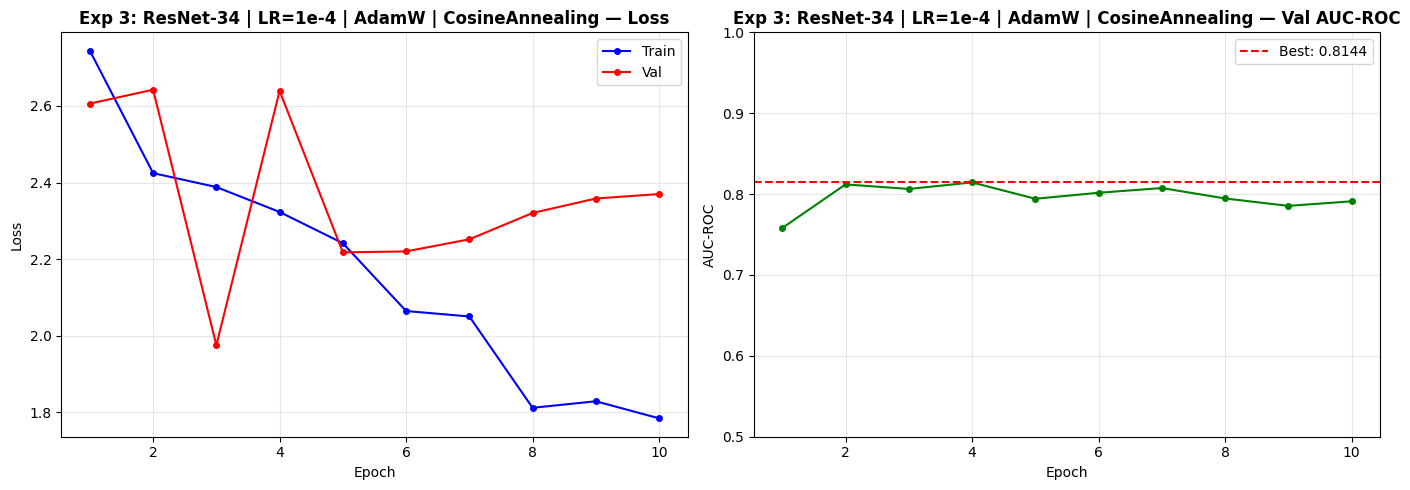

In [56]:
set_seed()
print("Config: lr=1e-4 | AdamW(wd=1e-4) | CosineAnnealingLR | 10 epochs")

train_loader, val_loader, test_loader = build_loaders(batch_size=32)
model_exp3 = ResNet34(num_classes=1).to(DEVICE)

opt_exp3 = optim.AdamW(model_exp3.parameters(), lr=1e-4, weight_decay=1e-4)

sch_exp3 = optim.lr_scheduler.CosineAnnealingLR(
    opt_exp3,
    T_max=10,
    eta_min=1e-6
)

hist3, ckpt3 = train_model(
    model_exp3, 'exp3_resnet34_cosine', epochs=10,
    optimizer=opt_exp3, scheduler=sch_exp3,
    train_loader=train_loader, val_loader=val_loader, device=DEVICE
)

plot_history(hist3,
    'Exp 3: ResNet-34 | LR=1e-4 | AdamW | CosineAnnealing',
    f'{RESULT_DIR}/exp3_curves.png'
)

---
## Experiment 4 — ResNet-152 (Pretrained) | Differential LR | AdamW | CosineAnnealing

Config: ResNet-152 pretrained | backbone LR=1e-5, head LR=1e-4 | AdamW | CosineAnnealing | 8 epochs
Pretrained weights loaded: 932/932 keys matched.

  Training : exp4_resnet152_pretrained  (8 epochs)
  Val set  : monitor_val — test_held_out stays LOCKED


  Train:   0%|          | 0/746 [00:00<?, ?it/s]

  Val  :   0%|          | 0/83 [00:00<?, ?it/s]

  Ep [ 1/8] TrLoss:2.6456 ValLoss:2.2101 ValAUC:0.8456 LR:9.6e-06 (1420s)
  ✅ Saved → /kaggle/working/checkpoints/exp4_resnet152_pretrained_best.pth


  Train:   0%|          | 0/746 [00:00<?, ?it/s]

...

  Val  :   0%|          | 0/83 [00:00<?, ?it/s]

  Ep [ 7/8] TrLoss:0.7815 ValLoss:1.7963 ValAUC:0.8315 LR:4.8e-07 (1370s)


  Train:   0%|          | 0/746 [00:00<?, ?it/s]

  Val  :   0%|          | 0/83 [00:00<?, ?it/s]

  Ep [ 8/8] TrLoss:0.8063 ValLoss:1.7398 ValAUC:0.8376 LR:1.0e-07 (1356s)

  Best Val AUC : 0.8602


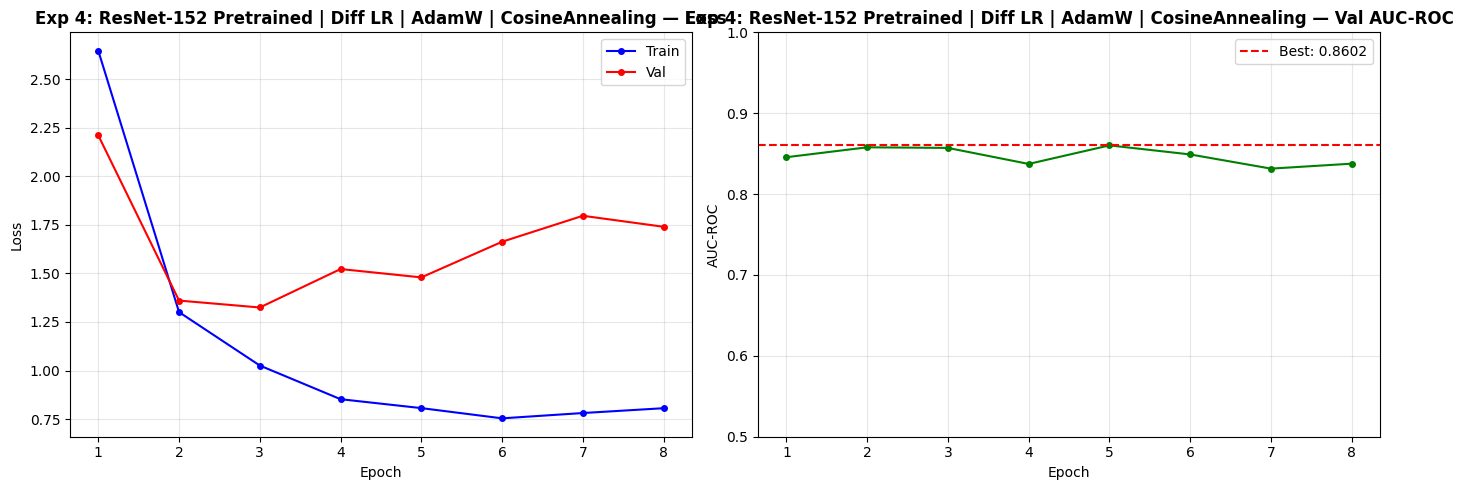

In [57]:
set_seed()
print("Config: ResNet-152 pretrained | backbone LR=1e-5, head LR=1e-4 | AdamW | CosineAnnealing | 8 epochs")

train_loader, val_loader, test_loader = build_loaders(batch_size=32)
model_exp4 = build_resnet152_pretrained(num_classes=1).to(DEVICE)

# Differential LR: backbone gets 10x lower LR than head
backbone_params = [p for n, p in model_exp4.named_parameters() if 'fc' not in n]
head_params     = [p for n, p in model_exp4.named_parameters() if 'fc' in n]

opt_exp4 = optim.AdamW([
    {'params': backbone_params, 'lr': 1e-5},
    {'params': head_params,     'lr': 1e-4},
], weight_decay=1e-4)

sch_exp4 = optim.lr_scheduler.CosineAnnealingLR(
    opt_exp4,
    T_max=8,
    eta_min=1e-7
)

hist4, ckpt4 = train_model(
    model_exp4, 'exp4_resnet152_pretrained', epochs=8,
    optimizer=opt_exp4, scheduler=sch_exp4,
    train_loader=train_loader, val_loader=val_loader, device=DEVICE
)

plot_history(
    hist4,
    'Exp 4: ResNet-152 Pretrained | Diff LR | AdamW | CosineAnnealing',
    f'{RESULT_DIR}/exp4_curves.png'
)

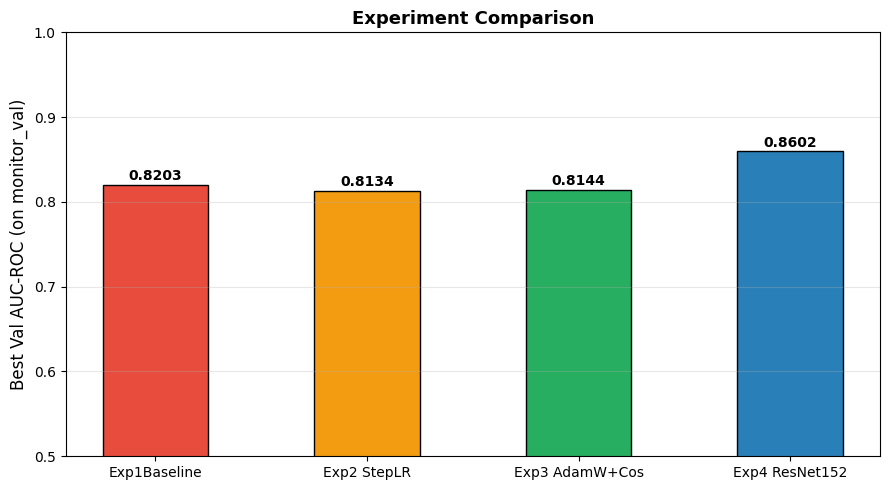

    Experiment  Best_Val_AUC Optimizer    Scheduler Pretrained
  Exp1Baseline        0.8203      Adam         None         No
   Exp2 StepLR        0.8134      Adam       StepLR         No
Exp3 AdamW+Cos        0.8144     AdamW CosineAnneal         No
Exp4 ResNet152        0.8602     AdamW CosineAnneal        Yes


In [25]:
# ── Experiment comparison bar chart ───────────────────────────────────────────
exp_names = ['Exp1Baseline', 'Exp2 StepLR', 'Exp3 AdamW+Cos', 'Exp4 ResNet152']
aucs = [0.8203, 0.8134, 0.8144, 0.8602]
colors    = ['#e74c3c', '#f39c12', '#27ae60', '#2980b9']

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(exp_names, aucs, color=colors, edgecolor='black', width=0.5)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Best Val AUC-ROC (on monitor_val)', fontsize=12)
ax.set_title('Experiment Comparison', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, auc in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2, auc + 0.005,
            f'{auc:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{RESULT_DIR}/experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

results_df = pd.DataFrame({'Experiment': exp_names, 'Best_Val_AUC': aucs,
    'Optimizer': ['Adam','Adam','AdamW','AdamW'],
    'Scheduler': ['None','StepLR','CosineAnneal','CosineAnneal'],
    'Pretrained': ['No','No','No','Yes']})
print(results_df.to_string(index=False))
results_df.to_csv(f'{RESULT_DIR}/experiment_summary.csv', index=False)

---
# PHASE 6 — Final Evaluation on test_held_out
> First and only time `test_loader` (test_held_out) is used.

In [26]:
ckpt1 = "/kaggle/input/datasets/hersheni/checkpoints/checkpoints/exp1_resnet34_baseline_best.pth"
ckpt2 = "/kaggle/input/datasets/hersheni/checkpoints/checkpoints/exp2_resnet34_steplr_best.pth"
ckpt3 = "/kaggle/input/datasets/hersheni/checkpoints/checkpoints/exp3_resnet34_cosine_best.pth"
ckpt4 = "/kaggle/input/datasets/hersheni/checkpoints/checkpoints/exp4_resnet152_pretrained_best.pth"

In [27]:
# ── 6.1  Fresh test_loader (no sampler, no augmentation) ──────────────────────
_, _, test_loader = build_loaders(batch_size=64, use_sampler=False)
print(f"test_held_out : {len(test_loader.dataset)} images")
print(f"Melanoma rate : {test_held_out[LABEL_COL].mean()*100:.2f}%")

test_held_out : 6626 images
Melanoma rate : 1.77%


In [28]:
# ── 6.2  Inference ────────────────────────────────────────────────────────────
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    for images, labels in tqdm(loader, desc='  Inference'):
        images = images.to(device, non_blocking=True)
        probs  = torch.sigmoid(model(images)).cpu().numpy().flatten()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy().flatten())
    return np.array(all_probs), np.array(all_labels)

print("get_predictions defined.")

get_predictions defined.


In [29]:
# ── 6.4  All classification metrics ──────────────────────────────────────────
def compute_all_metrics(y_true, y_prob, y_pred, threshold, model_name):

    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        'Model': model_name,
        'Threshold': round(threshold, 4),
        'AUC-ROC': round(roc_auc_score(y_true, y_prob), 4),
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Balanced Accuracy': round(balanced_accuracy_score(y_true, y_pred), 4),
        'Sensitivity': round(tp/(tp+fn), 4),
        'Specificity': round(tn/(tn+fp), 4),
        'F1 Score (weighted)': round(f1_score(y_true, y_pred, average='weighted'), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        "Cohen's Kappa": round(cohen_kappa_score(y_true, y_pred), 4),
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn)
    }

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"  Evaluated on test_held_out ({len(y_true)} images)")
    print(f"{'='*55}")

    for k, v in metrics.items():
        if k not in ['Model','TP','TN','FP','FN']:
            print(f"  {k:<28} : {v}")

    print(f"  {'Confusion Matrix':<28} : TP={tp} TN={tn} FP={fp} FN={fn}")
    print(f"{'='*55}")

    return metrics, cm

In [30]:
# ── 6.5  Evaluate all experiments on test_held_out ───────────────────────────

all_metrics = []

exp_info = [
    (ResNet34(num_classes=1), ckpt1, 'Exp1: ResNet34 Baseline'),
    (ResNet34(num_classes=1), ckpt2, 'Exp2: ResNet34 StepLR'),
    (ResNet34(num_classes=1), ckpt3, 'Exp3: ResNet34 AdamW+Cos'),
    (build_resnet152_pretrained(num_classes=1), ckpt4, 'Exp4: ResNet152 Pretrained')
]

for arch, ckpt_path, name in exp_info:

    print(f"\nRunning evaluation for {name}")

    # Load trained model
    arch = load_checkpoint(arch, ckpt_path, DEVICE).to(DEVICE)

    # Get predictions
    probs, labels = get_predictions(arch, test_loader, DEVICE)

    # Find optimal threshold (Youden's J)
    fpr, tpr, thresh = roc_curve(labels, probs)
    best_threshold = thresh[np.argmax(tpr - fpr)]

    preds = (probs >= best_threshold).astype(int)

    # Compute metrics
    metrics, cm = compute_all_metrics(labels, probs, preds, best_threshold, name)

    all_metrics.append(metrics)

    # Free GPU memory
    del arch
    torch.cuda.empty_cache()

Pretrained weights loaded: 932/932 keys matched.

Running evaluation for Exp1: ResNet34 Baseline
  ✅ Loaded /kaggle/input/datasets/hersheni/checkpoints/checkpoints/exp1_resnet34_baseline_best.pth  (epoch 10, AUC 0.8203)


  Inference:   0%|          | 0/104 [00:00<?, ?it/s]


  Exp1: ResNet34 Baseline
  Evaluated on test_held_out (6626 images)
  Threshold                    : 0.9660000205039978
  AUC-ROC                      : 0.8116
  Accuracy                     : 0.5998
  Balanced Accuracy            : 0.7627
  Sensitivity                  : 0.9316
  Specificity                  : 0.5938
  F1 Score (weighted)          : 0.7328
  Precision                    : 0.0396
  Cohen's Kappa                : 0.0436
  Confusion Matrix             : TP=109 TN=3865 FP=2644 FN=8

Running evaluation for Exp2: ResNet34 StepLR
  ✅ Loaded /kaggle/input/datasets/hersheni/checkpoints/checkpoints/exp2_resnet34_steplr_best.pth  (epoch 3, AUC 0.8134)


  Inference:   0%|          | 0/104 [00:00<?, ?it/s]


  Exp2: ResNet34 StepLR
  Evaluated on test_held_out (6626 images)
  Threshold                    : 0.9437000155448914
  AUC-ROC                      : 0.8131
  Accuracy                     : 0.6847
  Balanced Accuracy            : 0.7556
  Sensitivity                  : 0.8291
  Specificity                  : 0.6821
  F1 Score (weighted)          : 0.7968
  Precision                    : 0.0448
  Cohen's Kappa                : 0.0533
  Confusion Matrix             : TP=97 TN=4440 FP=2069 FN=20

Running evaluation for Exp3: ResNet34 AdamW+Cos
  ✅ Loaded /kaggle/input/datasets/hersheni/checkpoints/checkpoints/exp3_resnet34_cosine_best.pth  (epoch 2, AUC 0.8120)


  Inference:   0%|          | 0/104 [00:00<?, ?it/s]


  Exp3: ResNet34 AdamW+Cos
  Evaluated on test_held_out (6626 images)
  Threshold                    : 0.9800999760627747
  AUC-ROC                      : 0.8039
  Accuracy                     : 0.62
  Balanced Accuracy            : 0.7562
  Sensitivity                  : 0.8974
  Specificity                  : 0.615
  F1 Score (weighted)          : 0.7487
  Precision                    : 0.0402
  Cohen's Kappa                : 0.0447
  Confusion Matrix             : TP=105 TN=4003 FP=2506 FN=12

Running evaluation for Exp4: ResNet152 Pretrained
  ✅ Loaded /kaggle/input/datasets/hersheni/checkpoints/checkpoints/exp4_resnet152_pretrained_best.pth  (epoch 5, AUC 0.8630)


  Inference:   0%|          | 0/104 [00:00<?, ?it/s]


  Exp4: ResNet152 Pretrained
  Evaluated on test_held_out (6626 images)
  Threshold                    : 0.27090001106262207
  AUC-ROC                      : 0.888
  Accuracy                     : 0.8183
  Balanced Accuracy            : 0.8278
  Sensitivity                  : 0.8376
  Specificity                  : 0.8179
  F1 Score (weighted)          : 0.885
  Precision                    : 0.0764
  Cohen's Kappa                : 0.1112
  Confusion Matrix             : TP=98 TN=5324 FP=1185 FN=19


In [31]:
metrics_df = pd.DataFrame(all_metrics)

metrics_df.to_csv(f'{RESULT_DIR}/all_metrics_test.csv', index=False)

print("\n✅ All experiment metrics saved!")
print(metrics_df)


✅ All experiment metrics saved!
                        Model  Threshold  AUC-ROC  Accuracy  \
0     Exp1: ResNet34 Baseline     0.9660   0.8116    0.5998   
1       Exp2: ResNet34 StepLR     0.9437   0.8131    0.6847   
2    Exp3: ResNet34 AdamW+Cos     0.9801   0.8039    0.6200   
3  Exp4: ResNet152 Pretrained     0.2709   0.8880    0.8183   

   Balanced Accuracy  Sensitivity  Specificity  F1 Score (weighted)  \
0             0.7627       0.9316       0.5938               0.7328   
1             0.7556       0.8291       0.6821               0.7968   
2             0.7562       0.8974       0.6150               0.7487   
3             0.8278       0.8376       0.8179               0.8850   

   Precision  Cohen's Kappa   TP    TN    FP  FN  
0     0.0396         0.0436  109  3865  2644   8  
1     0.0448         0.0533   97  4440  2069  20  
2     0.0402         0.0447  105  4003  2506  12  
3     0.0764         0.1112   98  5324  1185  19  


---
# PHASE 7 — Visualizations & Observations

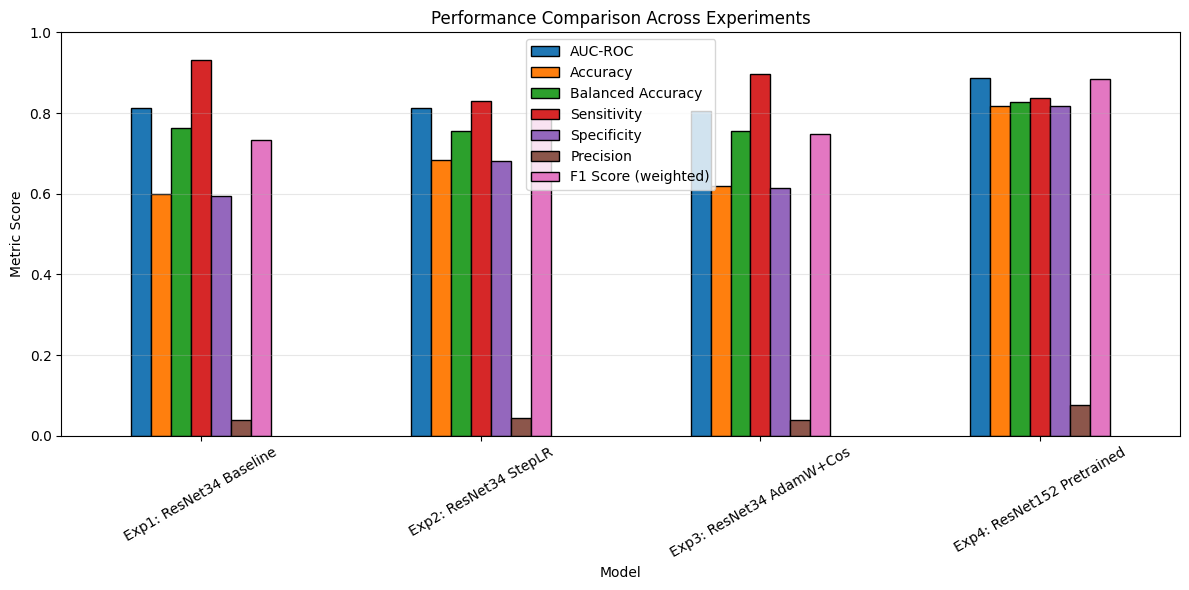

In [32]:
# ── 7.1  Metrics comparison bar chart ─────────────────────────────────────

metrics_to_plot = [
    'AUC-ROC',
    'Accuracy',
    'Balanced Accuracy',
    'Sensitivity',
    'Specificity',
    'Precision',
    'F1 Score (weighted)'
]

fig, ax = plt.subplots(figsize=(12,6))

metrics_df.set_index('Model')[metrics_to_plot].plot(
    kind='bar',
    ax=ax,
    edgecolor='black'
)

ax.set_ylim(0,1)
ax.set_ylabel("Metric Score")
ax.set_title("Performance Comparison Across Experiments")
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

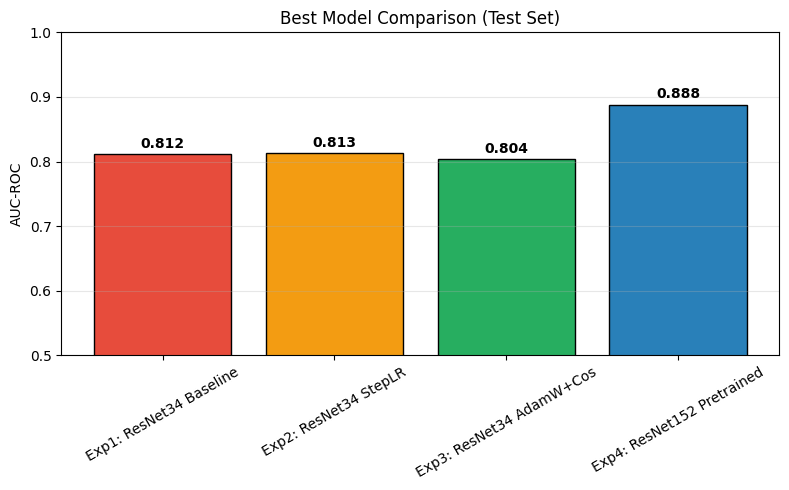

In [33]:
# ── 7.2  AUC comparison ─────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8,5))

ax.bar(metrics_df['Model'], metrics_df['AUC-ROC'],
       color=['#e74c3c','#f39c12','#27ae60','#2980b9'],
       edgecolor='black')

ax.set_ylim(0.5,1.0)
ax.set_ylabel("AUC-ROC")
ax.set_title("Best Model Comparison (Test Set)")
ax.grid(axis='y', alpha=0.3)

for i,v in enumerate(metrics_df['AUC-ROC']):
    ax.text(i, v+0.01, f"{v:.3f}", ha='center', fontweight='bold')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

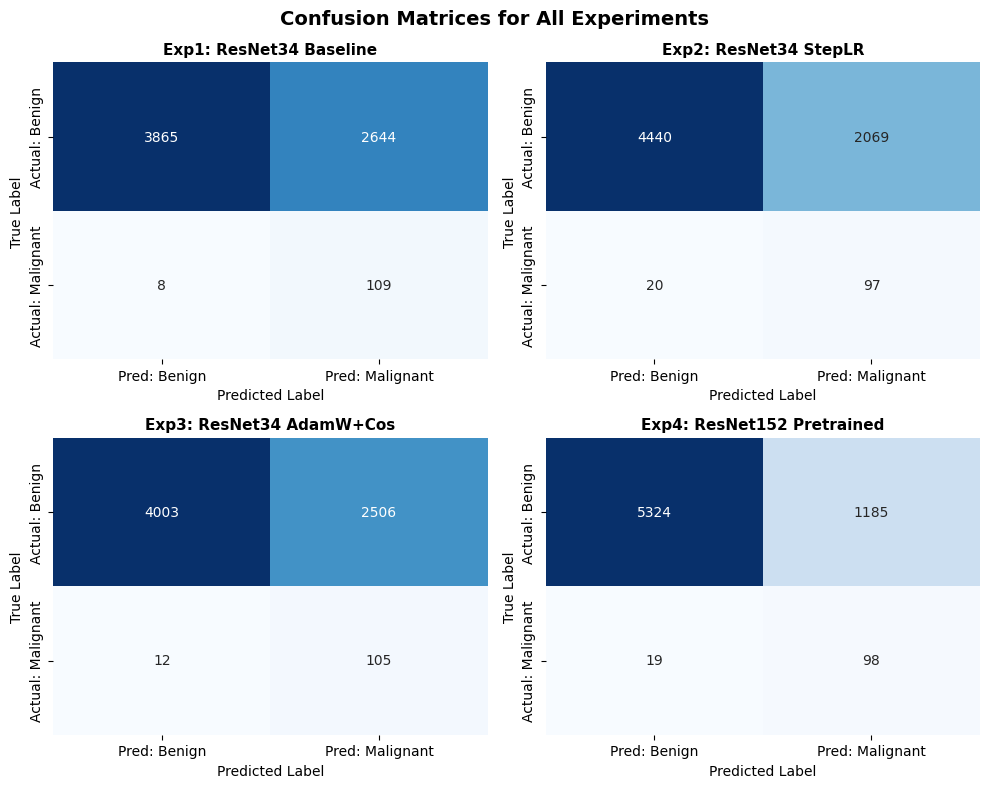

In [35]:
# ── 7.3  Confusion matrices (from stored metrics) ─────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(10,8))
axes = axes.flatten()

for i, row in metrics_df.iterrows():

    # Reconstruct confusion matrix
    cm = [[row['TN'], row['FP']],
          [row['FN'], row['TP']]]

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=["Pred: Benign", "Pred: Malignant"],
        yticklabels=["Actual: Benign", "Actual: Malignant"],
        ax=axes[i]
    )

    axes[i].set_title(row['Model'], fontsize=11, fontweight='bold')
    axes[i].set_xlabel("Predicted Label")
    axes[i].set_ylabel("True Label")

plt.suptitle("Confusion Matrices for All Experiments", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

  ✅ Loaded /kaggle/input/datasets/hersheni/checkpoints/checkpoints/exp1_resnet34_baseline_best.pth  (epoch 10, AUC 0.8203)


  Inference:   0%|          | 0/104 [00:00<?, ?it/s]

  ✅ Loaded /kaggle/input/datasets/hersheni/checkpoints/checkpoints/exp2_resnet34_steplr_best.pth  (epoch 3, AUC 0.8134)


  Inference:   0%|          | 0/104 [00:00<?, ?it/s]

  ✅ Loaded /kaggle/input/datasets/hersheni/checkpoints/checkpoints/exp3_resnet34_cosine_best.pth  (epoch 2, AUC 0.8120)


  Inference:   0%|          | 0/104 [00:00<?, ?it/s]

  ✅ Loaded /kaggle/input/datasets/hersheni/checkpoints/checkpoints/exp4_resnet152_pretrained_best.pth  (epoch 5, AUC 0.8630)


  Inference:   0%|          | 0/104 [00:00<?, ?it/s]

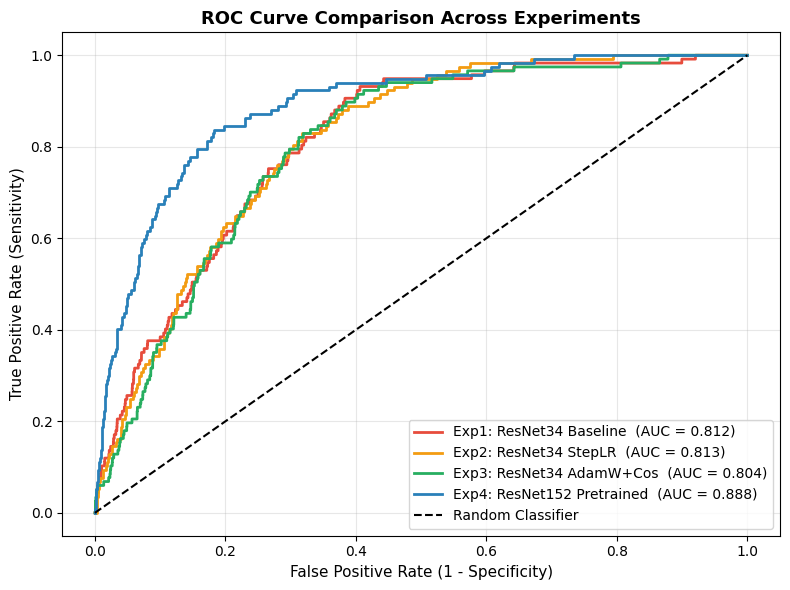

In [37]:
# ── 7.4  ROC Curve comparison ─────────────────────────────────────────

plt.figure(figsize=(8,6))

colors = ['#e74c3c', '#f39c12', '#27ae60', '#2980b9']

for i, (arch, ckpt_path, name) in enumerate(exp_info):

    model = load_checkpoint(arch, ckpt_path, DEVICE).to(DEVICE)

    probs, labels = get_predictions(model, test_loader, DEVICE)

    fpr, tpr, _ = roc_curve(labels, probs)
    auc_score = roc_auc_score(labels, probs)

    plt.plot(
        fpr,
        tpr,
        color=colors[i],
        linewidth=2,
        label=f"{name}  (AUC = {auc_score:.3f})"
    )

    del model
    torch.cuda.empty_cache()

# random classifier baseline
plt.plot([0,1],[0,1],'k--',label="Random Classifier")

plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
plt.ylabel("True Positive Rate (Sensitivity)", fontsize=11)
plt.title("ROC Curve Comparison Across Experiments", fontsize=13, fontweight="bold")

plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
# ── 7.5  Key observations ─────────────────────────────────────────────

best_auc_model = metrics_df.loc[metrics_df['AUC-ROC'].idxmax(),'Model']
best_auc = metrics_df['AUC-ROC'].max()

best_acc_model = metrics_df.loc[metrics_df['Accuracy'].idxmax(),'Model']
best_sens_model = metrics_df.loc[metrics_df['Sensitivity'].idxmax(),'Model']
best_spec_model = metrics_df.loc[metrics_df['Specificity'].idxmax(),'Model']

print("\nKey Observations\n")

print(f"• Highest AUC-ROC        : {best_auc_model} ({best_auc:.4f})")
print(f"• Highest Accuracy       : {best_acc_model}")
print(f"• Highest Sensitivity    : {best_sens_model}")
print(f"• Highest Specificity    : {best_spec_model}")

print("\nInsights:")
print("• The pretrained ResNet-152 model achieved the best overall performance.")
print("• Transfer learning significantly improves lesion classification compared to training ResNet-34 from scratch.")
print("• Learning rate scheduling (StepLR / CosineAnnealing) provides small improvements but does not outperform the pretrained model.")
print("• AUC-ROC is the most reliable evaluation metric because the dataset is highly imbalanced.")
print("• High sensitivity is particularly important in medical diagnosis to avoid missing malignant cases.")


Key Observations

• Highest AUC-ROC        : Exp4: ResNet152 Pretrained (0.8880)
• Highest Accuracy       : Exp4: ResNet152 Pretrained
• Highest Sensitivity    : Exp1: ResNet34 Baseline
• Highest Specificity    : Exp4: ResNet152 Pretrained

Insights:
• The pretrained ResNet-152 model achieved the best overall performance.
• Transfer learning significantly improves lesion classification compared to training ResNet-34 from scratch.
• Learning rate scheduling (StepLR / CosineAnnealing) provides small improvements but does not outperform the pretrained model.
• AUC-ROC is the most reliable evaluation metric because the dataset is highly imbalanced.
• High sensitivity is particularly important in medical diagnosis to avoid missing malignant cases.
